In [1]:
# %% Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
from pathlib import Path

In [3]:
# %% Setup Paths
current_dir = Path.cwd()

if current_dir.name == 'notebooks':
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir
    
print(f"Current Directory: {current_dir}")
print(f"Project Root detected at: {PROJECT_ROOT}")

data_path = PROJECT_ROOT / 'dataset' / 'finesse_dataset.csv'

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

df = pd.read_csv(data_path)
print(f"Dataset successfully loaded from: {data_path}")

Current Directory: /mnt/d/DBS CodingCamp/Finesse - Gamified Budgeting & Financial Health Scorer/notebooks
Project Root detected at: /mnt/d/DBS CodingCamp/Finesse - Gamified Budgeting & Financial Health Scorer
Dataset successfully loaded from: /mnt/d/DBS CodingCamp/Finesse - Gamified Budgeting & Financial Health Scorer/dataset/finesse_dataset.csv


In [4]:
# %% 1. Feature Engineering
# Grouping data per user
user_data = df.groupby('user_id').agg(
    total_spent=('amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    monthly_budget=('monthly_budget', 'first')
).reset_index()

# Smart feature: Budget Utilization Ratio
user_data['budget_utilization'] = user_data['total_spent'] / user_data['monthly_budget']

In [5]:
# %% 2. Data Scaling
features = ['total_spent', 'transaction_count', 'budget_utilization']
X = user_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

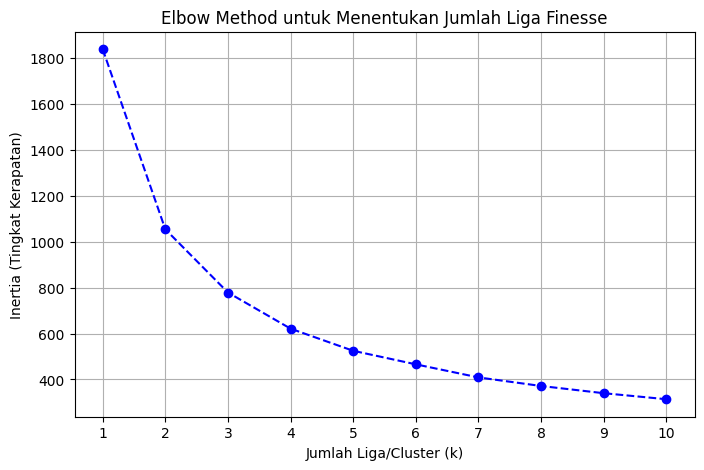

In [12]:
# %% 2.5 Elbow Method for Visualization (For Report Documentation)
# Analisis ini hanya perlu dijalankan sekali untuk membuktikan k=4 adalah optimal
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Grafik Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method untuk Menentukan Jumlah Liga Finesse')
plt.xlabel('Jumlah Liga/Cluster (k)')
plt.ylabel('Inertia (Tingkat Kerapatan)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [13]:
# %% 3. Train Final K-Means Model (k=4 based on Elbow Method)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
user_data['Cluster'] = kmeans_final.fit_predict(X_scaled)

In [16]:
# %% 4. Dynamic Cluster Mapping
# Menghitung rata-rata budget_utilization untuk setiap cluster
cluster_means = user_data.groupby('Cluster')['budget_utilization'].mean().sort_values()

# Mengurutkan dari yang paling hemat (Gold) ke paling boros (Iron)
league_names = ["Gold", "Silver", "Bronze", "Iron"]
league_mapping = {}
missions_mapping = {}

# Pemetaan dinamis berdasarkan urutan pemakaian budget
for i, (cluster_id, mean_util) in enumerate(cluster_means.items()):
    league_mapping[cluster_id] = league_names[i]
    
    # Assign misi berdasarkan liga
    if league_names[i] == "Gold":
        missions_mapping[cluster_id] = "Pertahankan prestasimu! Tabung 10% sisa uang cash kamu."
    elif league_names[i] == "Silver":
        missions_mapping[cluster_id] = "Kamu sedikit impulsif! Batasi 1 transaksi per hari."
    elif league_names[i] == "Bronze":
        missions_mapping[cluster_id] = "Awas over-budget! Tunda beli barang non-esensial."
    elif league_names[i] == "Iron":
        missions_mapping[cluster_id] = "🚨 DARURAT! Jangan jajan di luar 5 hari ke depan!"

# Tambahkan nama liga ke dataframe untuk visualisasi
user_data['League'] = user_data['Cluster'].map(league_mapping)

print("\n=== PROFIL 4 LIGA FINESSE ===")
analysis = user_data.groupby('League').agg(
    jumlah_user=('user_id', 'count'),
    rata_pengeluaran=('total_spent', 'mean'),
    rata_transaksi=('transaction_count', 'mean'),
    rata_utilisasi=('budget_utilization', 'mean')
).sort_values(by='rata_utilisasi')

# Formatting for readability
analysis['rata_pengeluaran'] = analysis['rata_pengeluaran'].apply(lambda x: f"Rp {x:,.0f}")
analysis['rata_utilisasi'] = analysis['rata_utilisasi'].apply(lambda x: f"{x*100:.1f}%")
analysis['rata_transaksi'] = analysis['rata_transaksi'].round(1)
print(analysis)


=== PROFIL 4 LIGA FINESSE ===
        jumlah_user rata_pengeluaran  rata_transaksi rata_utilisasi
League                                                             
Gold            206     Rp 2,253,490            20.8          83.9%
Silver          169     Rp 3,773,751            29.9         140.2%
Bronze          161     Rp 4,718,491            23.0         177.1%
Iron             77     Rp 6,976,234            28.6         308.2%


In [17]:
# %% 5. Evaluation
sil_score = silhouette_score(X_scaled, user_data['Cluster'])
print(f"\nSilhouette Score (k=4): {sil_score:.3f}")


Silhouette Score (k=4): 0.330


In [18]:
# %% 6. Export Models and Mappings
# Define the directory
save_dir = PROJECT_ROOT / 'saved_models' / 'Machine_Learning'

# Create the directory if it doesn't exist
save_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(scaler, save_dir / 'scaler_finesse.pkl')
joblib.dump(kmeans_final, save_dir / 'kmeans_finesse.pkl')
# Menyimpan kamus pemetaan agar API tahu cluster mana yang Gold/Iron
joblib.dump({'leagues': league_mapping, 'missions': missions_mapping}, save_dir / 'league_mapping.pkl') 

print(f"\nModel K-Means, Scaler, dan Mapping berhasil diekspor ke: {save_dir}")


Model K-Means, Scaler, dan Mapping berhasil diekspor ke: /mnt/d/DBS CodingCamp/Finesse - Gamified Budgeting & Financial Health Scorer/saved_models/Machine_Learning
